# Task 1
## Exploratory Data Analysis

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import DataLoader
from src.data.validator import DatasetValidator
from src.eda.analyzer import EDAAnalyzer
from src.eda.visualizer import EDAVisualizer

In [2]:
loader = DataLoader('../dataset/students_dataset.csv')
df = loader.load_data()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,48.0,1.0,4.0,124.0,274.0,0.0,2.0,166.0,0.0,0.5,2.0,0.0,7.0,1
1,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0,0
2,54.0,0.0,2.0,132.0,288.0,1.0,2.0,159.0,1.0,0.0,1.0,1.0,3.0,0
3,54.0,1.0,2.0,108.0,309.0,0.0,0.0,156.0,0.0,0.0,1.0,0.0,7.0,0
4,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1


In [3]:
validator = DatasetValidator(df)

print("Shape:", validator.check_shape())
print("\nDtypes:\n", validator.check_dtypes())
print("\nDuplicates:", validator.check_duplicates())
print("\nMissing Values:\n", validator.check_missing_values())
print("\nTarget Distribution:\n", validator.class_distribution("num"))

Shape: (242, 14)

Dtypes:
 age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object

Duplicates: 0

Missing Values:
 ca      1
thal    1
dtype: int64

Target Distribution:
 num
0    0.541322
1    0.458678
Name: proportion, dtype: float64


In [4]:
analyzer = EDAAnalyzer(df)

stats = analyzer.descriptive_statistics()
stats

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,241.000000,241.000000,242.000000
mean,54.549587,0.681818,3.152893,130.958678,249.838843,0.144628,0.979339,149.962810,0.326446,0.999174,1.586777,0.609959,4.713693,0.458678
std,8.996981,0.466736,0.975516,17.622551,52.846867,0.352454,0.999786,22.686449,0.469885,1.122940,0.613397,0.883497,1.948552,0.499322
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,2.250000,120.000000,212.000000,0.000000,0.000000,134.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,244.500000,0.000000,0.000000,153.500000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,277.750000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


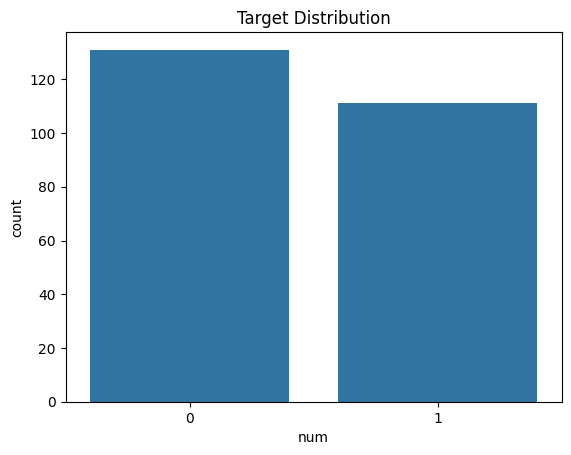

In [5]:
sns.countplot(x=df["num"])
plt.title("Target Distribution")
plt.show()

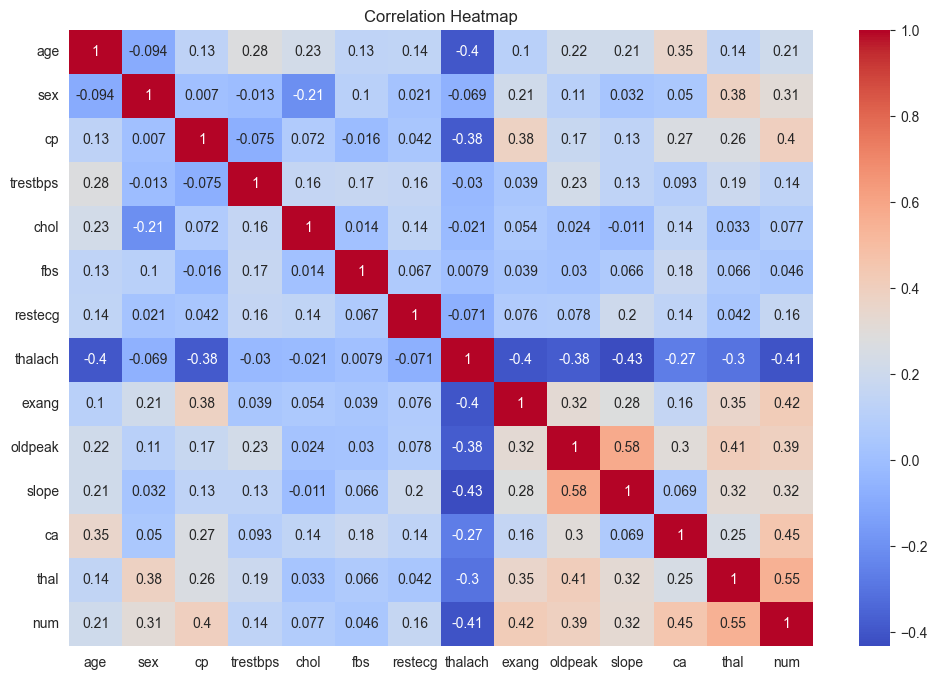

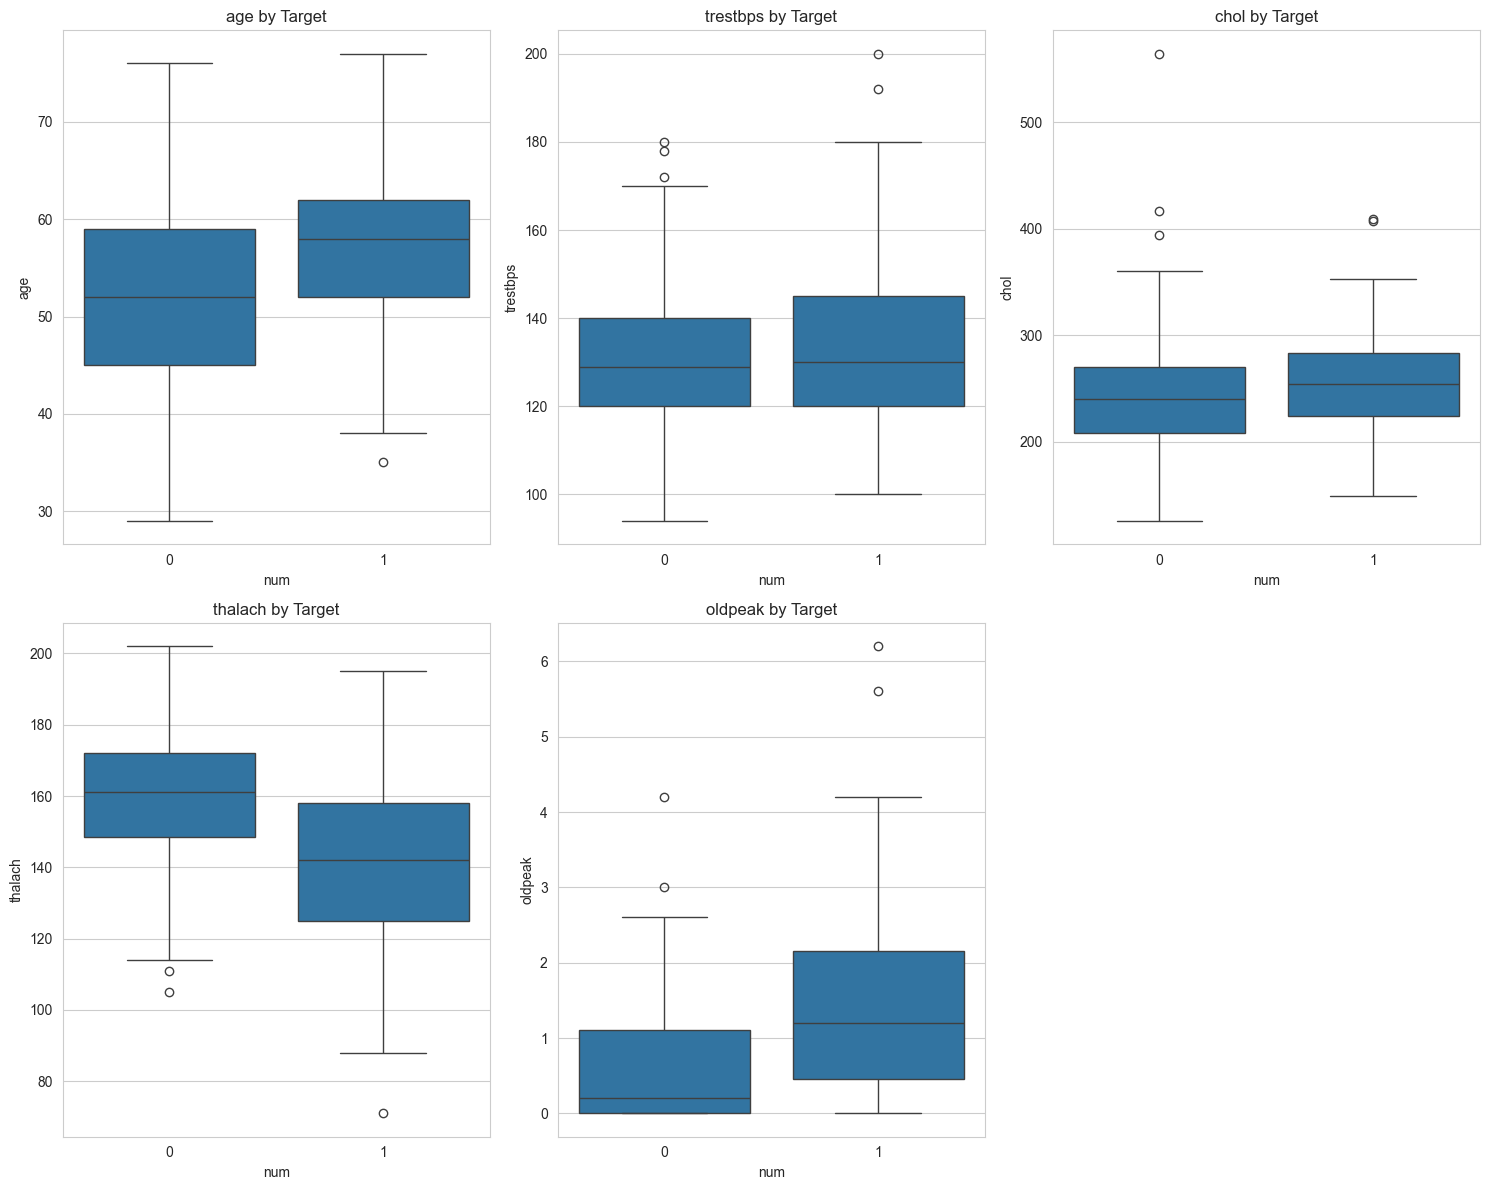

In [6]:
visualizer = EDAVisualizer()

corr = analyzer.correlation_matrix()
visualizer.plot_correlation_heatmap(corr)

continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
visualizer.plot_distributions(df, continuous_features, "num")

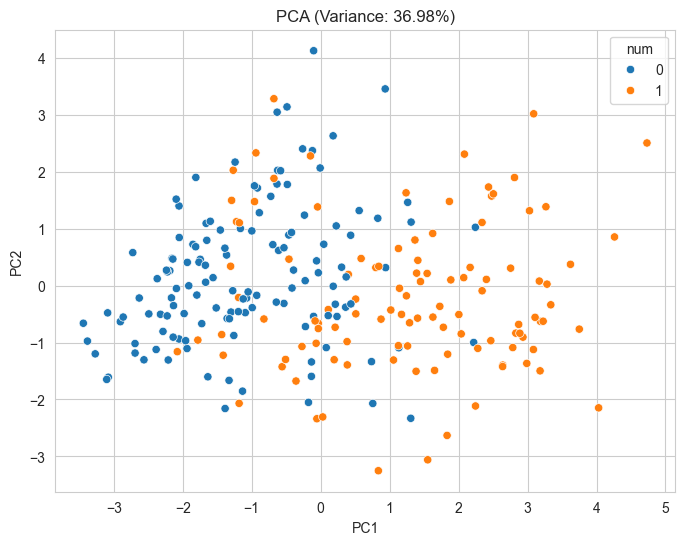

In [7]:
# PCA
X = df.drop(columns=["num"])
y = df["num"]

# For now we simply drop missing values
X_clean = X.dropna() 
y_clean = df.loc[X_clean.index, "num"]

coords, variance = analyzer.run_pca(X_clean)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=y_clean)
plt.title(f"PCA (Variance: {sum(variance):.2%})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

The PCA plot shows a significant amount of overlap between the two classes (no heart disease vs. presence of heart disease).
This suggests that a simple linear boundary may not be sufficient for high accuracy, and more complex, non-linear models will likely be necessary to capture the relationships in the data.

# Task 2
## Intuition & Preparation for the nCV Implementation

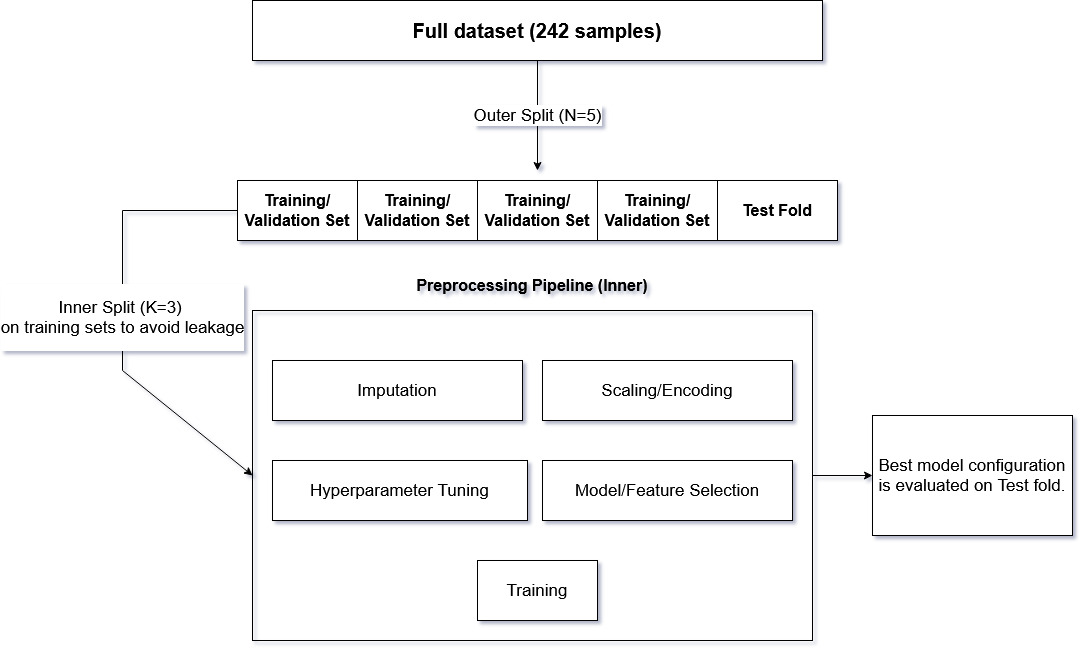

In [8]:
from IPython.display import Image
Image(filename='Diagram.jpg') 

**Outer Loop (N=5):** The 242 patient records are split into 5 folds. One fold is set aside as the **Test Fold (unseen data)**, and the other four become the **Outer Training Sets**.  

**Inner Loop (K=3):** The Outer Training Set is split into 3 folds. This loop is mainly used for Hyperparameter Tuning and model selection. 

**Preprocessing Pipeline:** Inside each split, the data passes through:

- Imputation: To handle missing clinical values.  
- Scaling/Encoding: To prepare continuous and categorical features.  
- Feature Selection: To identify the most informative predictors.  
- Training: The algorithm is trained on the processed inner folds.  

**Winning Params & Evaluation:** The best hyperparameters found in the inner loop are used to train a model on the Outer Training Set. This model then makes predictions on the Test Fold.

Repeat...

# Task 3
## Nested Cross-Validation Implementation

In [9]:
from src.cv.nested_cv import RepeatedNestedCV, FeatureSelectingRNCV

In [10]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Define the estimators
estimators = {
    'LR': LogisticRegression(solver="saga", max_iter=5000, random_state=42),
    'GNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'RF': RandomForestClassifier(random_state=42),
    'XGB': XGBClassifier(random_state=42),
    'LGBM': LGBMClassifier(random_state=42),
    'CB': CatBoostClassifier(silent=True, allow_writing_files=False, random_state=42)
}

# Define hyperparameter spaces
param_grids = {
    'LR': {
        'clf__C': [0.1, 1, 10],
        'clf__l1_ratio': [0.2, 0.5, 0.8]
    },
    'GNB': {},
    'LDA': {
        'clf__solver': ['svd', 'lsqr']
    },
    'RF': {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [None, 10, 20],
        'clf__min_samples_split': [2, 5]
    },
    'XGB': {
        'clf__learning_rate': [0.01, 0.1],
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [3, 6]
    },
    'LGBM': {
        'clf__learning_rate': [0.01, 0.1],
        'clf__num_leaves': [31, 50]
    },
    'CB': {
        'clf__depth': [4, 6],
        'clf__learning_rate': [0.01, 0.1]
    }
}

In [11]:
cv = RepeatedNestedCV()

# --- Baseline Comparison (No Inner Loop) ---
empty_grids = {name: {} for name in estimators.keys()}
print("Starting Baseline Comparison...")
baseline_results = cv.run(X, y, estimators, empty_grids)

# --- Full nested CV (With Tuning) ---
print("\nStarting Full Nested CV...")
full_ncv_results = cv.run(X, y, estimators, param_grids)

Starting Baseline Comparison...
Processing algorithm: LR
Processing algorithm: GNB
Processing algorithm: LDA
Processing algorithm: RF
Processing algorithm: XGB
Processing algorithm: LGBM
[LightGBM] [Info] Number of positive: 88, number of negative: 105
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 219
[LightGBM] [Info] Number of data points in the train set: 193, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.455959 -> initscore=-0.176624
[LightGBM] [Info] Start training from score -0.176624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

d:\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 89, number of negative: 104
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 217
[LightGBM] [Info] Number of data points in the train set: 193, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.461140 -> initscore=-0.155755
[LightGBM] [Info] Start training from score -0.155755
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

d:\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 89, number of negative: 105
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000057 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 215
[LightGBM] [Info] Number of data points in the train set: 194, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458763 -> initscore=-0.165324
[LightGBM] [Info] Start training from score -0.165324
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

...

d:\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 89, number of negative: 105
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 221
[LightGBM] [Info] Number of data points in the train set: 194, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458763 -> initscore=-0.165324
[LightGBM] [Info] Start training from score -0.165324
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

d:\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 89, number of negative: 105
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 218
[LightGBM] [Info] Number of data points in the train set: 194, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458763 -> initscore=-0.165324
[LightGBM] [Info] Start training from score -0.165324
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

d:\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [12]:
summary_data = []

for name, df_results in full_ncv_results.items():
    # Calculate median and 95% Confidence Intervals (Bootstrap approach)
    medians = df_results.median()
    
    # Store for comparison
    row = {
        'Algorithm': name,
        'Median_MCC': medians['MCC'],
        'Median_AUC': medians['AUC'],
        'Median_BA': medians['BA'],
        'Median_F1': medians['F1']
    }
    summary_data.append(row)

# Create summary table
summary_df = pd.DataFrame(summary_data).sort_values(by='Median_MCC', ascending=False)
print("\n--- Final Performance Summary (Sorted by MCC) ---")
print(summary_df)


--- Final Performance Summary (Sorted by MCC) ---
  Algorithm  Median_MCC  Median_AUC  Median_BA  Median_F1
0        LR    0.666845    0.897080   0.825887   0.804255
2       LDA    0.666671    0.896587   0.823427   0.808511
1       GNB    0.641599    0.891932   0.817156   0.800000
3        RF    0.585369    0.876064   0.786390   0.761905
6        CB    0.579979    0.868752   0.788138   0.761905
5      LGBM    0.569336    0.853033   0.777486   0.755556
4       XGB    0.540542    0.847756   0.769231   0.755556


Looking at these results, Logistic Regression (LR) and LDA are the top performers. Since it's a relatively small dataset, it makes sense that simpler "linear" models outperform more complex ones like XGBoost or CatBoost, which tend to overfit the noise.

# Task 4
## Feature Selection

In [13]:
# Initialize and run
selector_cv = FeatureSelectingRNCV(n_rounds=10, n_outer=5, n_inner=3)
reduced_results = selector_cv.run_with_selection(X, y, estimators['LR'], param_grids['LR'])

# Compare Performance
print("--- Comparison ---")
print("Full Baseline (MCC):", full_ncv_results['LR']['MCC'].median())
print("Reduced Set (MCC):", reduced_results['MCC'].median())

# Report Feature Stability 
print("\n--- Feature Selection Frequency (%) ---")
for feat, count in selector_cv.feature_frequencies.most_common():
    percentage = (count / 50) * 100 # Total 50 folds (10 rounds * 5 folds)
    print(f"{feat}: {percentage:.1f}%")

--- Comparison ---
Full Baseline (MCC): 0.6668451173307393
Reduced Set (MCC): 0.6535305536035086

--- Feature Selection Frequency (%) ---
sex: 100.0%
ca: 100.0%
thal: 100.0%
cp: 94.0%
exang: 68.0%
thalach: 40.0%
oldpeak: 22.0%
slope: 8.0%
trestbps: 2.0%


Even though the Reduced Set MCC is slightly lower than the Full Baseline, the difference is marginal, which suggests that a much smaller subset of features can achieve nearly the same predictive power.  

Sex, ca, and thal: These are the most stable features, selected in every single fold across all 10 rounds. This indicates they are the strongest, most consistent predictors of heart disease in the dataset.  

cp: Chest pain type is almost universally selected, further confirming its high importance.  

exang: Exercise-induced angina is a strong secondary predictor.

Low Frequency Features: trestbps and slope were almost never selected, suggesting they provide redundant information or noise for the Logistic Regression model.